In [ ]:
!pip install numpy pandas matplotlib scikit-learn tensorflow

from google.colab import files
uploaded = files.upload()  # Select your CSV file manually



Saving sitting_testing.csv to sitting_testing (1).csv
Saving sitting_training.csv to sitting_training (1).csv
Saving standing_testing.csv to standing_testing.csv
Saving standing_training.csv to standing_training.csv
Saving walking_testing.csv to walking_testing.csv
Saving walking_training.csv to walking_training.csv


Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.4729 - loss: 1.0673 - val_accuracy: 0.5426 - val_loss: 0.9820
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6476 - loss: 0.9360 - val_accuracy: 0.5426 - val_loss: 0.9086
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6281 - loss: 0.8446 - val_accuracy: 0.5426 - val_loss: 0.8715
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6625 - loss: 0.7423 - val_accuracy: 0.5426 - val_loss: 0.8582
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.6054 - loss: 0.7519 - val_accuracy: 0.5426 - val_loss: 0.8120
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.6913 - loss: 0.6685 - val_accuracy: 0.6383 - val_loss: 0.7545
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.7771 - loss: 0.6287 - val_accuracy: 0.7021 - val_loss: 0.7043
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8115 - loss: 0.5308 - val_accuracy: 0.7340 - v

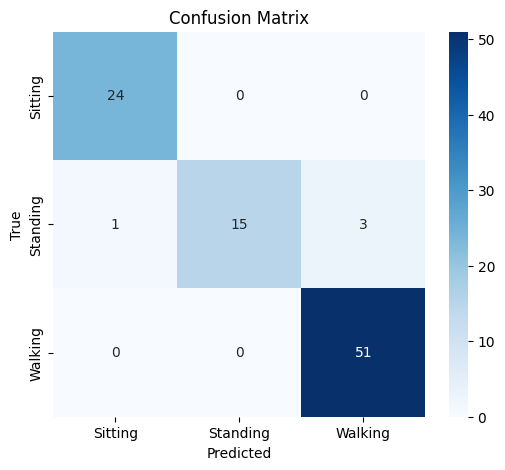

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load all CSVs
sitting_train = pd.read_csv("sitting_training.csv")
sitting_test = pd.read_csv("sitting_testing.csv")
standing_train = pd.read_csv("standing_training.csv")
standing_test = pd.read_csv("standing_testing.csv")
walking_train = pd.read_csv("walking_training.csv")
walking_test = pd.read_csv("walking_testing.csv")

# Label data
sitting_train['label'] = 'Sitting'
sitting_test['label'] = 'Sitting'
standing_train['label'] = 'Standing'
standing_test['label'] = 'Standing'
walking_train['label'] = 'Walking'
walking_test['label'] = 'Walking'

# Combine datasets
train_df = pd.concat([sitting_train, standing_train, walking_train], ignore_index=True)
test_df = pd.concat([sitting_test, standing_test, walking_test], ignore_index=True)

# Split features and labels
X_train = train_df.drop(columns=['label']).values
y_train = train_df['label'].values
X_test = test_df.drop(columns=['label']).values
y_test = test_df['label'].values

# Normalize
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)

# Reshape for CNN
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# CNN model
model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # 3 output classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
model.fit(X_train, y_train_cat, epochs=20, validation_data=(X_test, y_test_cat))

# Predict
y_pred = model.predict(X_test)
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = np.argmax(y_test_cat, axis=1)

# Report
print("\nClassification Report:")
print(classification_report(y_true_class, y_pred_class, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_true_class, y_pred_class)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
